# Dataset Nature Analysis: Polymer (PI1M) vs Molecular (MOSES)

**Research Question (a):** How does the nature of the dataset - polymeric (longer PSMILES from PI1M) vs. molecular (shorter SMILES from MOSES) - affect the dynamic tokenization learnt?

## Comparisons

We'll compare models trained on the same conditions but different datasets:

### Non-concatenated, 5 epoch:
- **PI1M**: `PI1M_noconcat_5epoch`
- **MOSES**: `MOSES_noconcat_5epoch`

### Concatenated, 5 epoch:
- **PI1M**: `PI1M_concat_5epoch`
- **MOSES**: `MOSES_concat_5epoch`

## Analysis Goals
1. Compare token distributions between polymer and molecular datasets
2. Analyze top tokens and breakpoint characters
3. Compare token length distributions
4. Quantify differences (KL divergence, Jaccard similarity)
5. Visualize differences in learned tokenization strategies


In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Setup plotting style
sns.set_style("whitegrid")
sns.set_context("talk")
colors = sns.color_palette("mako", 10)
plt.rcParams['figure.figsize'] = (14, 8)

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

# Import analysis utilities
from analysis.utils.statistics import TokenStatistics, compare_token_distributions, compute_kl_divergence

print("Imports successful!")
print(f"Project root: {project_root}")


/opt/pytorch/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Imports successful!
Project root: /home/ec2-user/hnet_smiles


## 1. Load Statistics

Load pre-computed statistics for the models we'll compare.


In [2]:
# Load statistics for models to compare
stats_dir = project_root / 'analysis' / 'data' / 'statistics'

# Non-concatenated comparison (5 epoch)
pi1m_noconcat = TokenStatistics.load(str(stats_dir / 'PI1M_noconcat_5epoch_stats.json'))
moses_noconcat = TokenStatistics.load(str(stats_dir / 'MOSES_noconcat_5epoch_stats.json'))

# Concatenated comparison (5 epoch)
pi1m_concat = TokenStatistics.load(str(stats_dir / 'PI1M_concat_5epoch_stats.json'))
moses_concat = TokenStatistics.load(str(stats_dir / 'MOSES_concat_5epoch_stats.json'))

print("✓ Statistics loaded successfully!")


✓ Statistics loaded successfully!


## 2. Comparison: Non-concatenated Models

Compare PI1M vs MOSES for non-concatenated training (5 epoch).


In [3]:
# Compare distributions
comparison_noconcat = compare_token_distributions(
    pi1m_noconcat, moses_noconcat,
    label1="PI1M (polymer)", label2="MOSES (molecular)"
)

print("="*60)
print("Non-concatenated Comparison: PI1M vs MOSES")
print("="*60)
print(f"\nToken Overlap:")
print(f"  Jaccard Similarity: {comparison_noconcat['token_overlap']['jaccard_similarity']:.4f}")
print(f"  Unique to PI1M: {comparison_noconcat['token_overlap']['unique_to_1']}")
print(f"  Unique to MOSES: {comparison_noconcat['token_overlap']['unique_to_2']}")

print(f"\nBreakpoint Overlap:")
print(f"  Jaccard Similarity: {comparison_noconcat['breakpoint_overlap']['jaccard_similarity']:.4f}")
print(f"  Unique to PI1M: {comparison_noconcat['breakpoint_overlap']['unique_to_1']}")
print(f"  Unique to MOSES: {comparison_noconcat['breakpoint_overlap']['unique_to_2']}")

print(f"\nToken Length Differences:")
print(f"  Mean diff: {comparison_noconcat['length_comparison']['mean_diff']:.4f}")
print(f"  Median diff: {comparison_noconcat['length_comparison']['median_diff']:.4f}")

# Compute KL divergence
kl_div_noconcat = compute_kl_divergence(pi1m_noconcat, moses_noconcat)
print(f"\nKL Divergence (PI1M || MOSES): {kl_div_noconcat:.4f}")


Non-concatenated Comparison: PI1M vs MOSES

Token Overlap:
  Jaccard Similarity: 0.2987
  Unique to PI1M: 27
  Unique to MOSES: 27

Breakpoint Overlap:
  Jaccard Similarity: 0.5714
  Unique to PI1M: 17
  Unique to MOSES: 1

Token Length Differences:
  Mean diff: -0.2785
  Median diff: 0.0000

KL Divergence (PI1M || MOSES): 3.9149


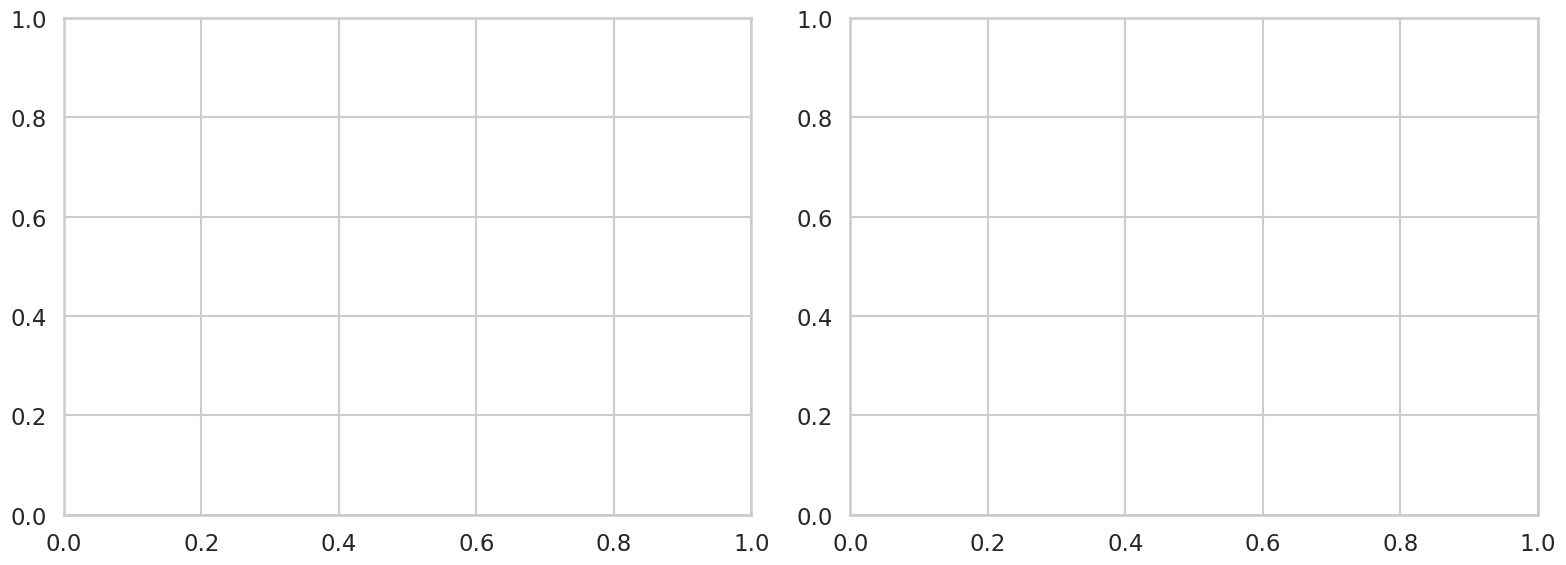

In [4]:
# Visualize token length distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PI1M
pi1m_lengths = pi1m_noconcat.stats.get('token_length_distribution', [])
if pi1m_lengths:
    axes[0].hist(pi1m_lengths, bins=30, color=colors[0], alpha=0.7, edgecolor='black')
    axes[0].axvline(np.mean(pi1m_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(pi1m_lengths):.2f}')
    axes[0].axvline(np.median(pi1m_lengths), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(pi1m_lengths):.2f}')
    axes[0].set_xlabel('Token Length (characters)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('PI1M (Polymer) - Token Length Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# MOSES
moses_lengths = moses_noconcat.stats.get('token_length_distribution', [])
if moses_lengths:
    axes[1].hist(moses_lengths, bins=30, color=colors[5], alpha=0.7, edgecolor='black')
    axes[1].axvline(np.mean(moses_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(moses_lengths):.2f}')
    axes[1].axvline(np.median(moses_lengths), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(moses_lengths):.2f}')
    axes[1].set_xlabel('Token Length (characters)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('MOSES (Molecular) - Token Length Distribution')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'analysis' / 'figures' / 'dataset_nature_token_lengths_noconcat.png', dpi=300, bbox_inches='tight')
plt.show()


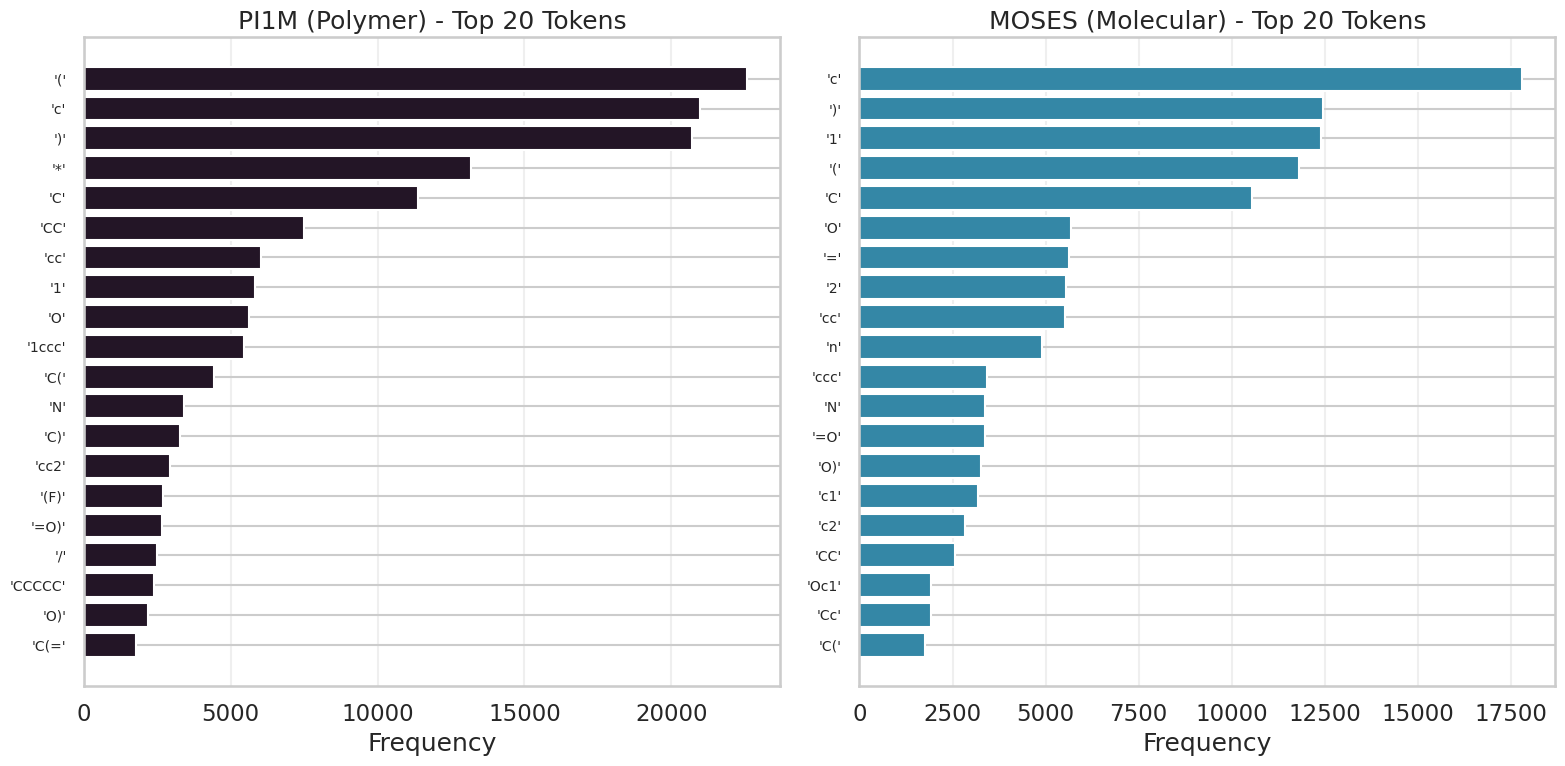

In [5]:
# Compare top tokens
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# PI1M top tokens
pi1m_top = pi1m_noconcat.get_top_tokens(20)
tokens_pi1m = [t[0] for t in pi1m_top]
counts_pi1m = [t[1] for t in pi1m_top]

axes[0].barh(range(len(tokens_pi1m)), counts_pi1m, color=colors[0])
axes[0].set_yticks(range(len(tokens_pi1m)))
axes[0].set_yticklabels([repr(t) for t in tokens_pi1m], fontsize=10)
axes[0].set_xlabel('Frequency')
axes[0].set_title('PI1M (Polymer) - Top 20 Tokens')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# MOSES top tokens
moses_top = moses_noconcat.get_top_tokens(20)
tokens_moses = [t[0] for t in moses_top]
counts_moses = [t[1] for t in moses_top]

axes[1].barh(range(len(tokens_moses)), counts_moses, color=colors[5])
axes[1].set_yticks(range(len(tokens_moses)))
axes[1].set_yticklabels([repr(t) for t in tokens_moses], fontsize=10)
axes[1].set_xlabel('Frequency')
axes[1].set_title('MOSES (Molecular) - Top 20 Tokens')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(project_root / 'analysis' / 'figures' / 'dataset_nature_top_tokens_noconcat.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Comparison: Concatenated Models

Compare PI1M vs MOSES for concatenated training (5 epoch).


In [6]:
# Compare distributions
comparison_concat = compare_token_distributions(
    pi1m_concat, moses_concat,
    label1="PI1M (polymer)", label2="MOSES (molecular)"
)

print("="*60)
print("Concatenated Comparison: PI1M vs MOSES")
print("="*60)
print(f"\nToken Overlap:")
print(f"  Jaccard Similarity: {comparison_concat['token_overlap']['jaccard_similarity']:.4f}")
print(f"  Unique to PI1M: {comparison_concat['token_overlap']['unique_to_1']}")
print(f"  Unique to MOSES: {comparison_concat['token_overlap']['unique_to_2']}")

print(f"\nBreakpoint Overlap:")
print(f"  Jaccard Similarity: {comparison_concat['breakpoint_overlap']['jaccard_similarity']:.4f}")

print(f"\nToken Length Differences:")
print(f"  Mean diff: {comparison_concat['length_comparison']['mean_diff']:.4f}")
print(f"  Median diff: {comparison_concat['length_comparison']['median_diff']:.4f}")

# Compute KL divergence
kl_div_concat = compute_kl_divergence(pi1m_concat, moses_concat)
print(f"\nKL Divergence (PI1M || MOSES): {kl_div_concat:.4f}")


Concatenated Comparison: PI1M vs MOSES

Token Overlap:
  Jaccard Similarity: 0.3333
  Unique to PI1M: 25
  Unique to MOSES: 25

Breakpoint Overlap:
  Jaccard Similarity: 0.5897

Token Length Differences:
  Mean diff: -0.6040
  Median diff: -1.0000

KL Divergence (PI1M || MOSES): 4.2676


## 4. Summary & Conclusions

Key findings on how dataset nature (polymer vs molecular) affects tokenization.


In [7]:
# Create summary comparison table
summary_data = {
    'Metric': [
        'Jaccard Similarity (Tokens)',
        'KL Divergence',
        'Mean Token Length Diff',
        'Jaccard Similarity (Breakpoints)',
    ],
    'Non-concatenated': [
        f"{comparison_noconcat['token_overlap']['jaccard_similarity']:.4f}",
        f"{kl_div_noconcat:.4f}",
        f"{comparison_noconcat['length_comparison']['mean_diff']:.4f}",
        f"{comparison_noconcat['breakpoint_overlap']['jaccard_similarity']:.4f}",
    ],
    'Concatenated': [
        f"{comparison_concat['token_overlap']['jaccard_similarity']:.4f}",
        f"{kl_div_concat:.4f}",
        f"{comparison_concat['length_comparison']['mean_diff']:.4f}",
        f"{comparison_concat['breakpoint_overlap']['jaccard_similarity']:.4f}",
    ],
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*60)
print("Summary: Dataset Nature Effect (PI1M vs MOSES)")
print("="*60)
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv(project_root / 'analysis' / 'data' / 'dataset_nature_summary.csv', index=False)

print("\n✓ Analysis complete! Figures saved to analysis/figures/")



Summary: Dataset Nature Effect (PI1M vs MOSES)
                          Metric Non-concatenated Concatenated
     Jaccard Similarity (Tokens)           0.2987       0.3333
                   KL Divergence           3.9149       4.2676
          Mean Token Length Diff          -0.2785      -0.6040
Jaccard Similarity (Breakpoints)           0.5714       0.5897

✓ Analysis complete! Figures saved to analysis/figures/
